In [20]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

PROJECT_ROOT = Path.cwd().parent
Result_dir = Path(PROJECT_ROOT/"results")

Feature_file = (Result_dir/"acoustic_features.csv")
df = pd.read_csv(Feature_file, dtype={"section":str})

print(df.shape)

feature_columns = [
    "rms",
    "zcr",
    "spectral_centroid",
    "spectral_bandwidth",
    "spectral_rolloff",
    "spectral_flatness"
]
df[feature_columns].isna().sum()

(4209, 12)


rms                   0
zcr                   0
spectral_centroid     0
spectral_bandwidth    0
spectral_rolloff      0
spectral_flatness     0
dtype: int64

In [21]:
SECTION = "00"

source_train = df[
    (df["section"] == SECTION) &
    (df["domain"] == "source") &
    (df["split"] == "train") &
    (df["label"] == "normal")
].copy()

print(f"Source train: {len(source_train)}")

source_test = df[
    (df["section"] == SECTION) &
    (df["domain"] == "source") &
    (df["split"] == "test")
].copy()

print(f"Source test: {len(source_test)}")

target_train = df[
    (df["section"] == SECTION) &
    (df["domain"] == "target") &
    (df["split"] == "train") &
    (df["label"] == "normal")
].copy()

print(f"target train: {len(target_train)}")

target_test = df[
    (df["section"] == SECTION) &
    (df["domain"] == "target") &
    (df["split"] == "test")
].copy()

print(f"target test: {len(target_test)}")

X_train_source = source_train[feature_columns]
y_train_source = source_train["label"]

X_test_source = source_test[feature_columns]
y_test_source = source_test["label"]

X_test_target = target_test[feature_columns]
y_test_target = target_test["label"]

Source train: 1000
Source test: 200
target train: 3
target test: 200


In [22]:
model = IsolationForest(
    n_estimators=300,
    contamination="auto",
    random_state=123,
    n_jobs=-1
)

model.fit(X_train_source)

IsolationForest(n_estimators=300, n_jobs=-1, random_state=123)

In [23]:
pred_source = model.predict(X_test_source)

y_pred_source = np.where(pred_source == 1, "normal", "anomaly")

In [24]:
def evaluate_model(y_true, y_pred):
    metrics = {
        "accuracy": accuracy_score(
            y_true,
            y_pred
        ),
        "precision": precision_score(
            y_true,
            y_pred,
            pos_label="anomaly"
        ),
        "recall": recall_score(
            y_true,
            y_pred,
            pos_label="anomaly"
        ),
        "f1": f1_score(
            y_true,
            y_pred,
            pos_label="anomaly"
        )
    }
    return metrics


def evaluate_predictions(y_true, y_pred, title, section="00"):
    results = evaluate_model(y_true, y_pred)
    
    cm = confusion_matrix(
        y_true,
        y_pred,
        labels=["normal","anomaly"]
    )

    disp = ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Normal", "Anomaly"]
    )

    disp.plot()
    plt.title(f"Section {section}: {title}") #"Isolation Forest - Source Test"
    plt.tight_layout()
    plt.show()

    return results

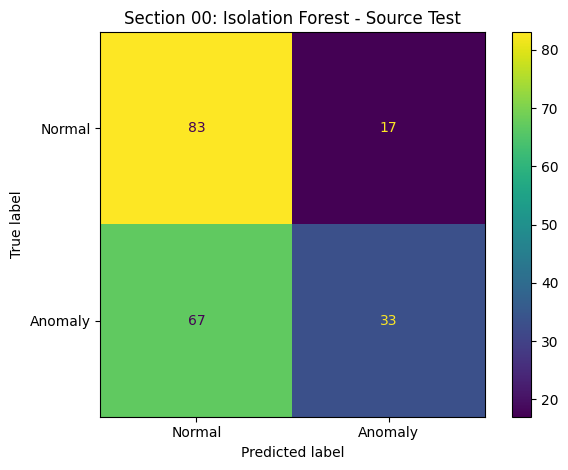

{'accuracy': 0.58, 'precision': np.float64(0.66), 'recall': np.float64(0.33), 'f1': np.float64(0.44)}


In [25]:
source_results = evaluate_predictions(y_test_source,y_pred_source,"Isolation Forest - Source Test")
print(source_results)

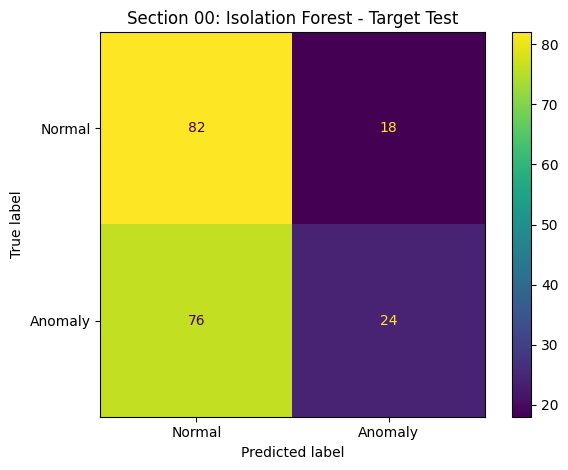

{'accuracy': 0.53, 'precision': np.float64(0.5714285714285714), 'recall': np.float64(0.24), 'f1': np.float64(0.3380281690140845)}


In [26]:
pred_target = model.predict(X_test_target)

y_pred_target = np.where(pred_target == 1, "normal", "anomaly")

target_results = evaluate_predictions(y_test_target, y_pred_target, "Isolation Forest - Target Test")

print(target_results)

In [27]:
adaptation_train = pd.concat(
    [
        source_train,
        target_train
    ],
    ignore_index=True
)

X_train_adapted = adaptation_train[feature_columns]

adapted_model = IsolationForest(
    n_estimators=300,
    contamination="auto",
    random_state=123,
    n_jobs=-1
)

adapted_model.fit(X_train_adapted)

IsolationForest(n_estimators=300, n_jobs=-1, random_state=123)

In [28]:
pred_target_adapted = adapted_model.predict(
    X_test_target
)

y_pred_target_adapted = np.where(pred_target_adapted==1, "normal", "anomaly")

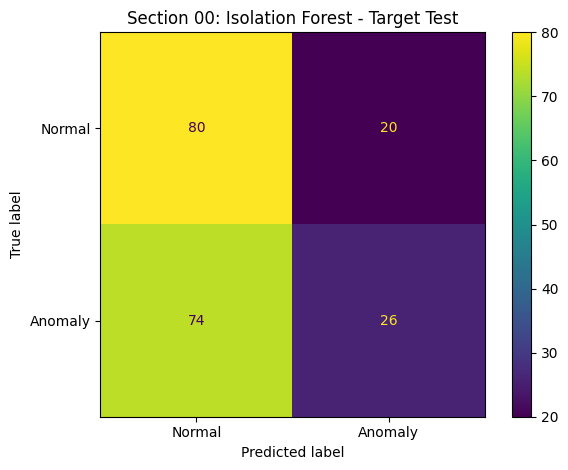

{'accuracy': 0.53, 'precision': np.float64(0.5652173913043478), 'recall': np.float64(0.26), 'f1': np.float64(0.3561643835616438)}


In [29]:
adapted_results = evaluate_predictions(
    y_test_target,
    y_pred_target_adapted,
    "Isolation Forest - Target Test"
)

print(adapted_results)


In [30]:
results = pd.DataFrame([
    {
        "experiment": "Source_Source",
        **source_results
    },
    {
        "experiment": "Source_Target",
        **target_results
    },
    {
        "experiment": "Source+Target_Target",
        **adapted_results
    }
])

results

,experiment,accuracy,precision,recall,f1
0,Source_Source,0.58,0.660000,0.33,0.440000
1,Source_Target,0.53,0.571429,0.24,0.338028
2,Source+Target_Target,0.53,0.565217,0.26,0.356164


In [31]:
def run_experiment(section, model, model_name):

    source_train = df[
        (df["section"] == section) &
        (df["domain"] == "source") &
        (df["split"] == "train") &
        (df["label"] == "normal")
    ].copy()

    source_test = df[
        (df["section"] == section) &
        (df["domain"] == "source") &
        (df["split"] == "test")
    ].copy()

    target_train = df[
        (df["section"] == section) &
        (df["domain"] == "target") &
        (df["split"] == "train") &
        (df["label"] == "normal")
    ].copy()

    target_test = df[
        (df["section"] == section) &
        (df["domain"] == "target") &
        (df["split"] == "test")
    ].copy()

    X_train_source = source_train[feature_columns]
    y_train_source = source_train["label"]

    X_test_source = source_test[feature_columns]
    y_test_source = source_test["label"]

    X_test_target = target_test[feature_columns]
    y_test_target = target_test["label"]

    model = model

    model.fit(X_train_source)
    pred_source = model.predict(X_test_source)

    y_pred_source = np.where(pred_source == 1, "normal", "anomaly")
    
    source_results = evaluate_predictions(y_test_source, y_pred_source, f"{model_name} - Source Test", section)
    
    pred_target = model.predict(X_test_target)

    y_pred_target = np.where(pred_target == 1, "normal", "anomaly")

    target_results = evaluate_predictions(y_test_target, y_pred_target, f"{model_name} - Target Test", section)


    adaptation_train = pd.concat(
        [
            source_train,
            target_train
        ],
        ignore_index=True
    )

    X_train_adapted = adaptation_train[feature_columns]

    adapted_model = model

    adapted_model.fit(X_train_adapted)

    pred_target_adapted = adapted_model.predict(
        X_test_target
    )

    y_pred_target_adapted = np.where(pred_target_adapted==1, "normal", "anomaly")

    adapted_results = evaluate_predictions(y_test_target, y_pred_target_adapted, f"{model_name} - Target Test", section)


    results = pd.DataFrame([
        {
            "experiment": "Source_Source",
            **source_results
        },
        {
            "experiment": "Source_Target",
            **target_results
        },
        {
            "experiment": "Source+Target_Target",
            **adapted_results
        }
    ])

    return results

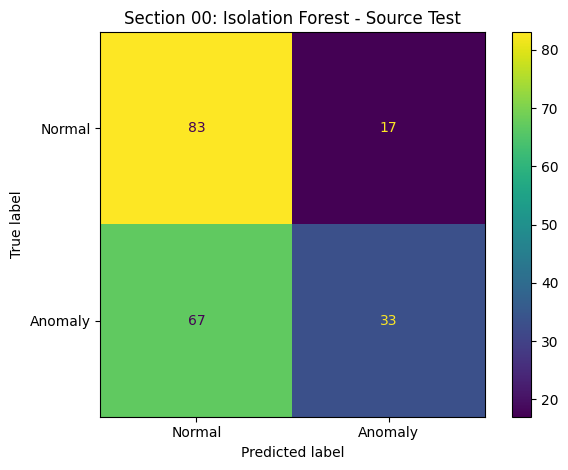

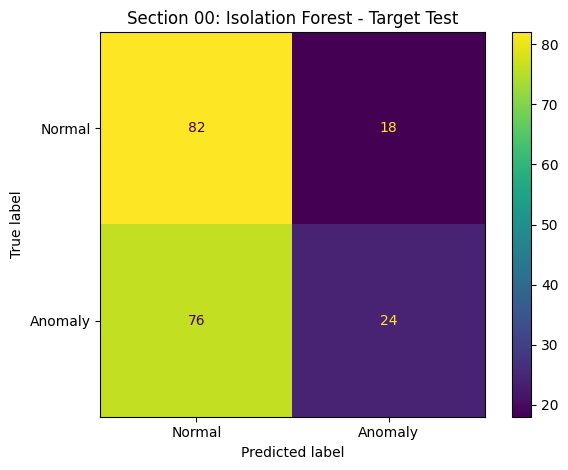

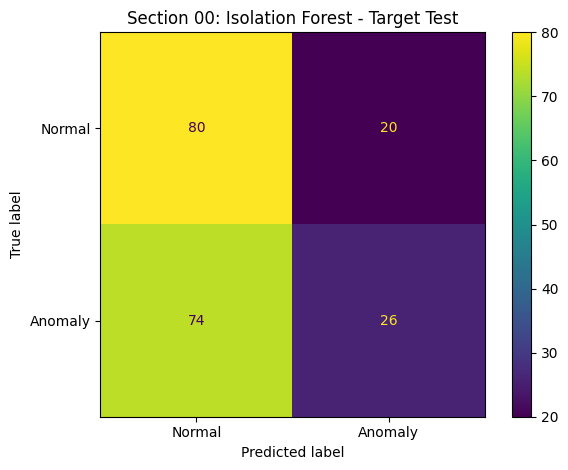

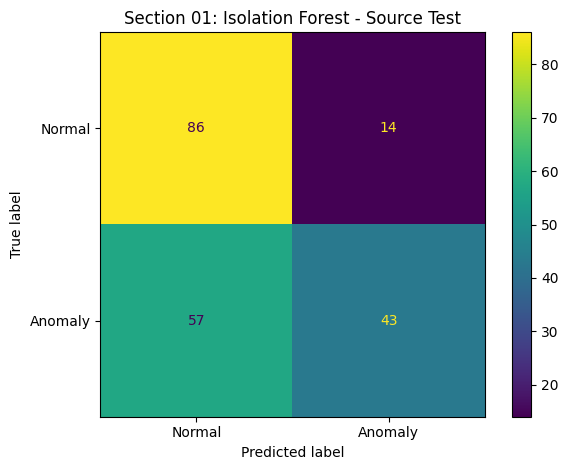

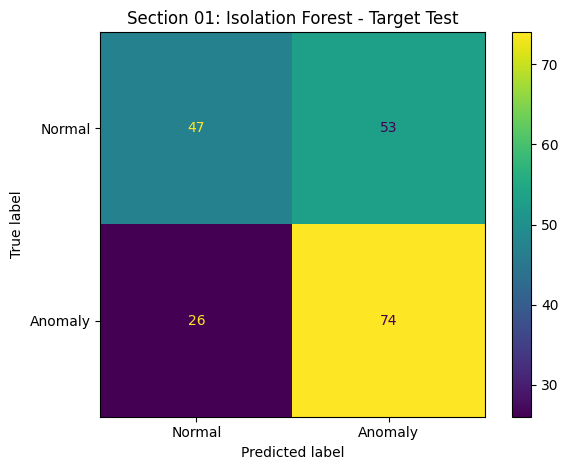

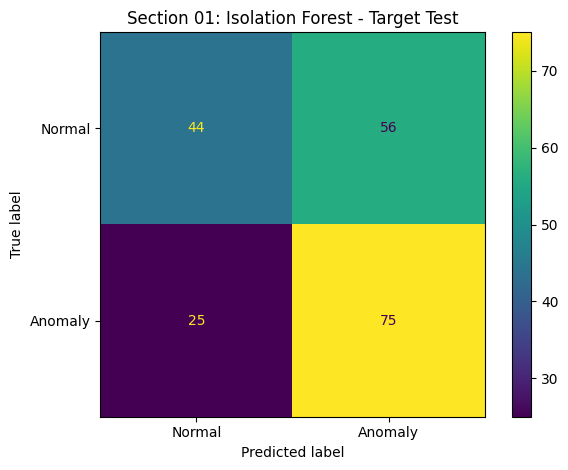

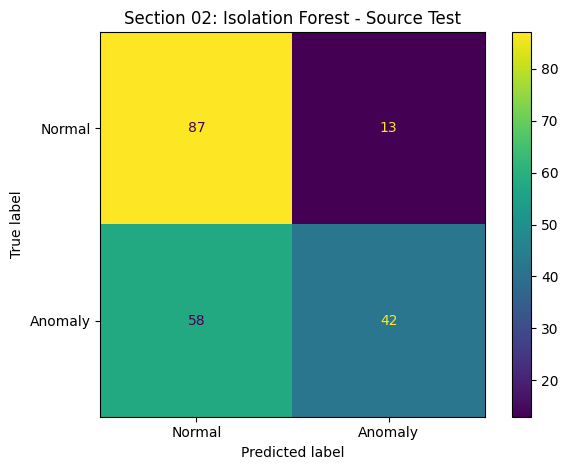

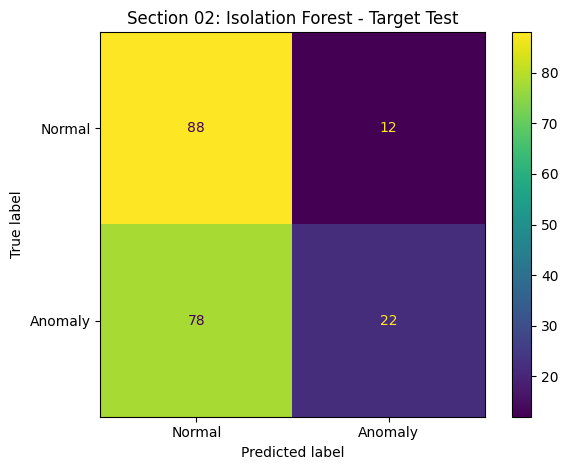

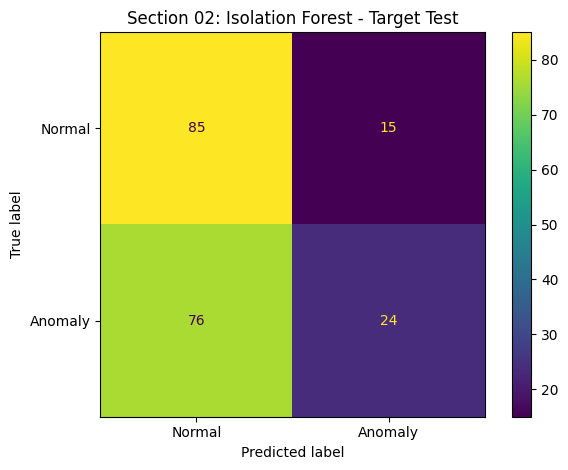

  section            model            experiment  accuracy  precision  recall  \
0      00  IsolationForest         Source_Source     0.580   0.660000    0.33   
1      00  IsolationForest         Source_Target     0.530   0.571429    0.24   
2      00  IsolationForest  Source+Target_Target     0.530   0.565217    0.26   
3      01  IsolationForest         Source_Source     0.645   0.754386    0.43   
4      01  IsolationForest         Source_Target     0.605   0.582677    0.74   
5      01  IsolationForest  Source+Target_Target     0.595   0.572519    0.75   
6      02  IsolationForest         Source_Source     0.645   0.763636    0.42   
7      02  IsolationForest         Source_Target     0.550   0.647059    0.22   
8      02  IsolationForest  Source+Target_Target     0.545   0.615385    0.24   

         f1  
0  0.440000  
1  0.338028  
2  0.356164  
3  0.547771  
4  0.651982  
5  0.649351  
6  0.541935  
7  0.328358  
8  0.345324  


In [32]:
model = IsolationForest(
    n_estimators=300,
    contamination="auto",
    random_state=123,
    n_jobs=-1
)

all_results = []

for section in ["00", "01", "02"]:
    results = run_experiment(section, model, "Isolation Forest")
    results["section"] = section
    results["model"] = "IsolationForest"
    all_results.append(results)

all_results = pd.concat(all_results, ignore_index=True)
cols = (
    ["section", "model"]
    + [c for c in all_results.columns if c not in ["section", "model"]]
)
all_results = all_results[cols]

print(all_results)

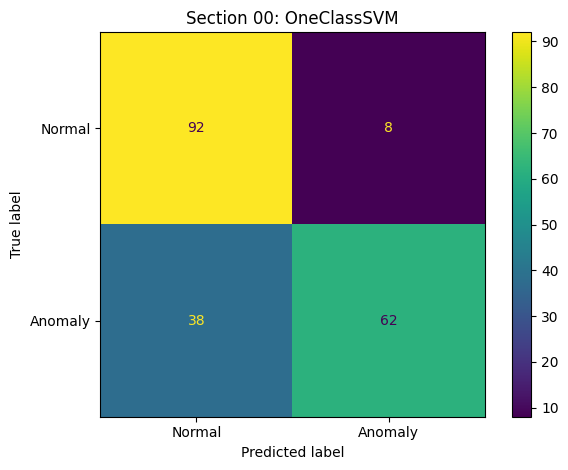

{'accuracy': 0.77, 'precision': np.float64(0.8857142857142857), 'recall': np.float64(0.62), 'f1': np.float64(0.7294117647058823)}


In [33]:
from sklearn.svm import OneClassSVM

model = Pipeline([
    (
        "scaler", StandardScaler()
    ),
    (
        "ocsvm", OneClassSVM(kernel="rbf", gamma="scale", nu=0.1)
    )
])

model.fit(X_train_source)
pred = model.predict(X_test_source)

y_pred = np.where(pred==1, "normal", "anomaly")

results = evaluate_predictions(y_test_source, y_pred, "OneClassSVM")
print(results)

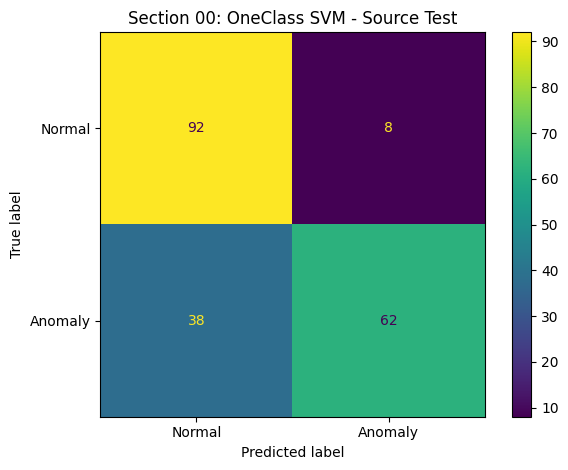

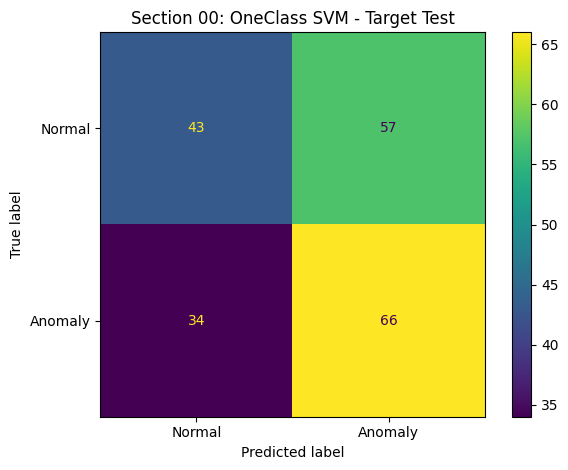

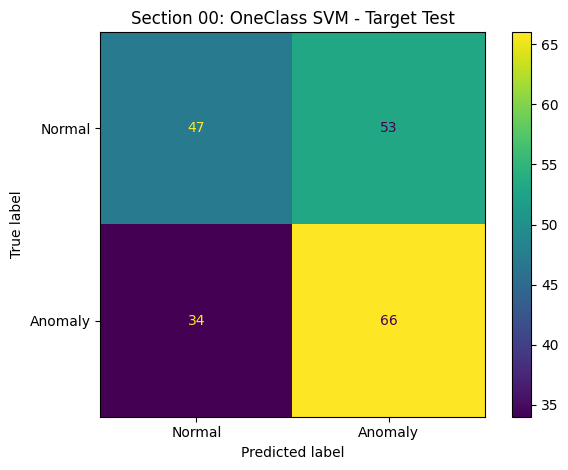

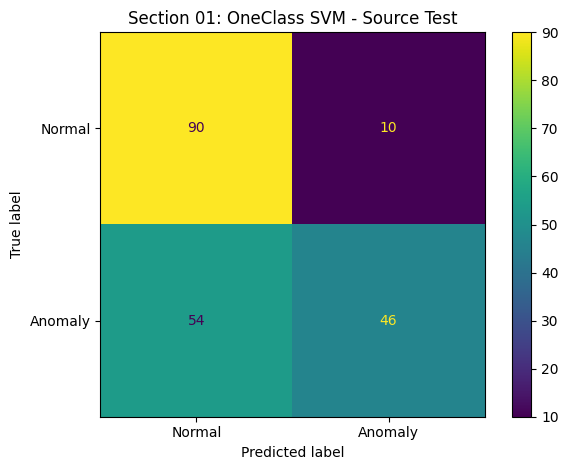

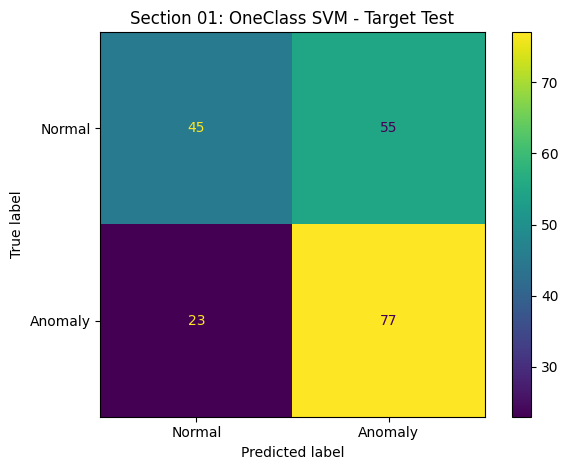

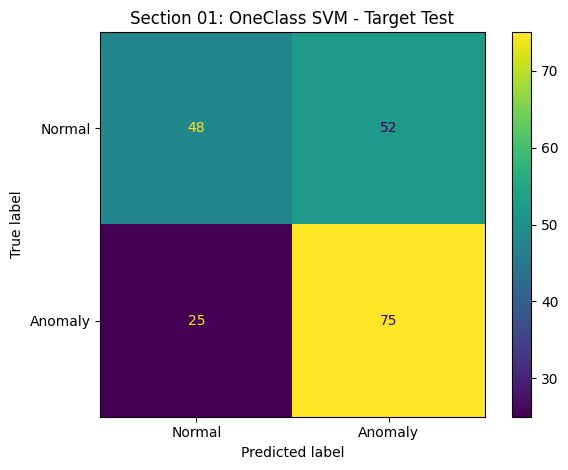

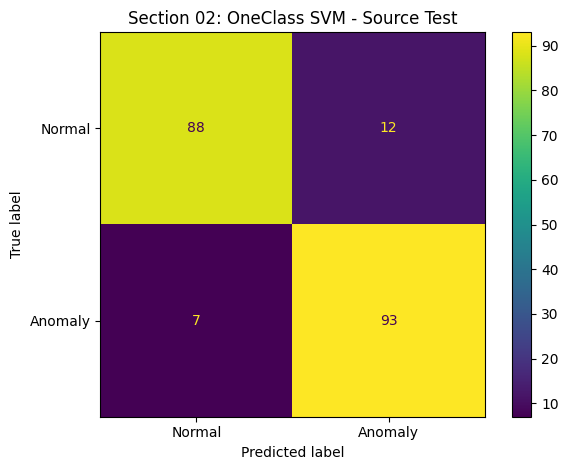

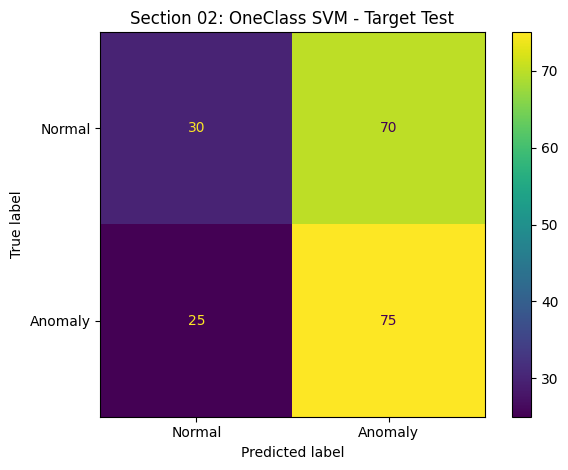

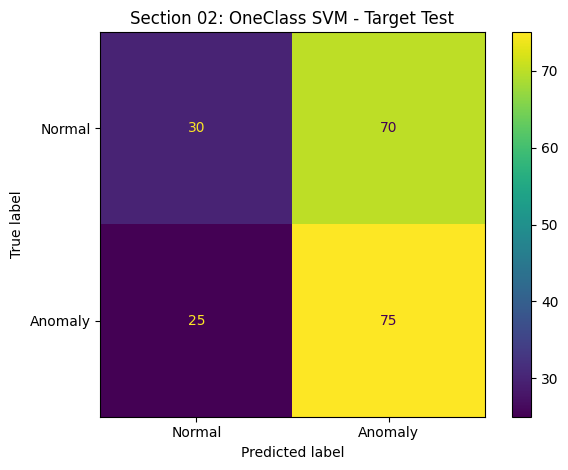

  section        model            experiment  accuracy  precision  recall  \
0      00  OneClassSVM         Source_Source     0.770   0.885714    0.62   
1      00  OneClassSVM         Source_Target     0.545   0.536585    0.66   
2      00  OneClassSVM  Source+Target_Target     0.565   0.554622    0.66   
3      01  OneClassSVM         Source_Source     0.680   0.821429    0.46   
4      01  OneClassSVM         Source_Target     0.610   0.583333    0.77   
5      01  OneClassSVM  Source+Target_Target     0.615   0.590551    0.75   
6      02  OneClassSVM         Source_Source     0.905   0.885714    0.93   
7      02  OneClassSVM         Source_Target     0.525   0.517241    0.75   
8      02  OneClassSVM  Source+Target_Target     0.525   0.517241    0.75   

         f1  
0  0.729412  
1  0.591928  
2  0.602740  
3  0.589744  
4  0.663793  
5  0.660793  
6  0.907317  
7  0.612245  
8  0.612245  


In [34]:
model = Pipeline([
    (
        "scaler", StandardScaler()
    ),
    (
        "ocsvm", OneClassSVM(kernel="rbf", gamma="scale", nu=0.1)
    )
])

all_results_svm = []

for section in ["00", "01", "02"]:
    results = run_experiment(section, model, "OneClass SVM")
    results["section"] = section
    results["model"] = "OneClassSVM"
    all_results_svm.append(results)

all_results_svm = pd.concat(all_results_svm, ignore_index=True)
cols = (
    ["section", "model"]
    + [c for c in all_results.columns if c not in ["section", "model"]]
)
all_results_svm = all_results_svm[cols]

print(all_results_svm)

In [35]:
results = pd.concat([
    all_results,
    all_results_svm
])

results.to_csv(Result_dir/"baseline_results.csv", index=False)

In [36]:
cnn_results = pd.read_csv(Result_dir/"cnn_ae_results.csv", dtype={"section":str})
cnn_results["model"] = "CNNAE"
cols = (
    ["section", "model"]
    + [c for c in cnn_results.columns if c not in ["section", "model"]]
)
cnn_results = cnn_results[cols]
cnn_results.head()

,section,model,experiment,accuracy,precision,recall,f1
0,00,CNNAE,Source_Source,0.505,0.508475,0.30,0.377358
1,00,CNNAE,Source_Target,0.525,0.608696,0.14,0.227642
2,00,CNNAE,Source+Target_Target,0.530,0.636364,0.14,0.229508
3,01,CNNAE,Source_Source,0.485,0.478873,0.34,0.397661
4,01,CNNAE,Source_Target,0.530,0.600000,0.18,0.276923


In [43]:
f1_results = pd.concat([
    results,
    cnn_results
])

f1_results = f1_results[
    f1_results["experiment"] == "Source_Target"][["section","model","f1"]
].copy()


f1_results.columns = ["Section","Model","F1"]

f1_results["Model"] = f1_results["Model"].replace({
    "IsolationForest": "Isolation Forest",
    "OneClassSVM": "One-Class SVM",
    "CNNAE": "CNN-AE"
})

print(f1_results)

  Section             Model        F1
1      00  Isolation Forest  0.338028
4      01  Isolation Forest  0.651982
7      02  Isolation Forest  0.328358
1      00     One-Class SVM  0.591928
4      01     One-Class SVM  0.663793
7      02     One-Class SVM  0.612245
1      00            CNN-AE  0.227642
4      01            CNN-AE  0.276923
7      02            CNN-AE  0.057692


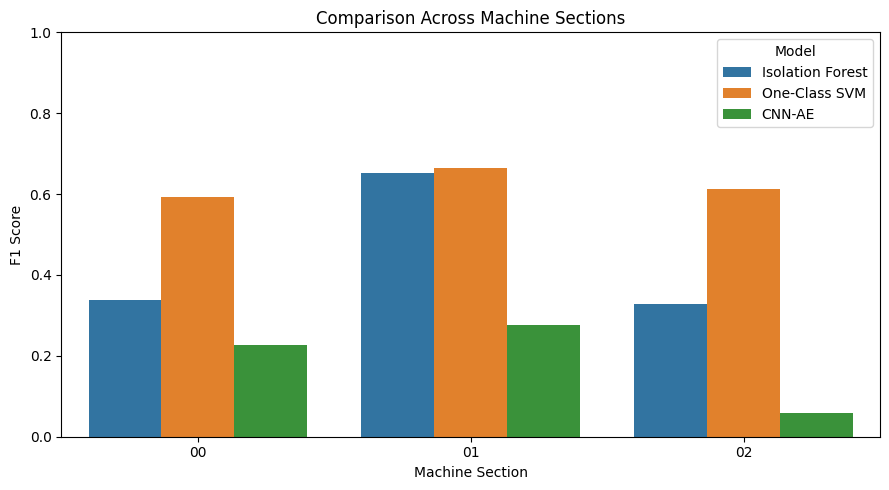

In [44]:
import seaborn as sns

plt.figure(figsize=(9,5))

sns.barplot(
    data=f1_results,
    x="Section",
    y="F1",
    hue="Model"
)

plt.ylabel("F1 Score")
plt.xlabel("Machine Section")
plt.title("Comparison Across Machine Sections")
plt.ylim(0,1)

plt.tight_layout()
plt.show()